In [1]:
files = []

MIN = 0
MAX = 250

for i in range(MIN+1, MAX+1):
    files.append(f"../data/pinecone/{i:03d}.txt")

In [2]:
# Get bits
epsilon = []
all_contents = []

for file in files:
    with open(file, "r") as f:
        contents = f.readlines()
        all_contents.append(contents)
    
    for c in contents:
        c = c.strip()
        if len(c) == 0:
            continue
        for bit in c:
            epsilon.append(int(bit))

In [3]:
with open(f"../data/pinecone/all.txt", "w") as f:
    for content in all_contents:
        for c in content:
            f.write(c)

In [4]:
# Change representation (Step 1)
X = []

for e in epsilon:
    X.append((2*e) - 1)

In [5]:
# Compute partial sums ( Step 2 + 3)
import numpy as np

def partial_sum(X):
    S = [0] # Already attach leading zero (see step 3)
    
    sum = 0
    last_was_positive = False
    running = 0
    longest_running = 0
    for i in range(len(X)):
        next = X[i]
        sum += next
        S.append(sum)
        
        if next > 0 and last_was_positive:
            running += 1
        elif next < 0 and last_was_positive:
            last_was_positive = False
            running = 0
        elif next > 0 and not last_was_positive:
            last_was_positive = True
            running = 0
        else:
            running += 1
            
        if running > longest_running:
            longest_running = running
        
    # Attach trailing zero (step 3)
    S.append(0)
    
    return S, longest_running

In [6]:
S, longest = partial_sum(X)

In [7]:
len(X)

250000000

In [8]:
len(S)

250000002

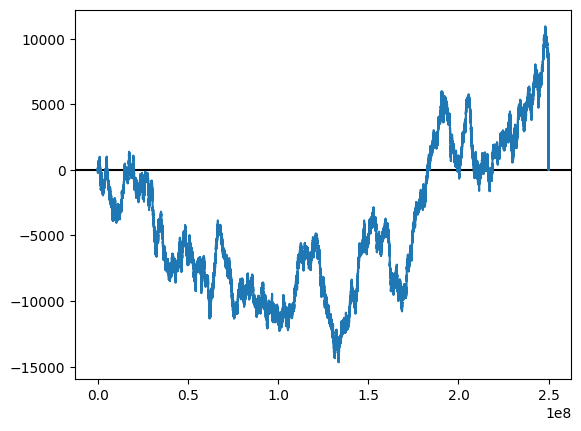

In [9]:
# Draw random walk
import matplotlib.pyplot as plt

# Set axes
x = np.arange(0, len(S), 1)
y, _ = partial_sum(X)

# Plot
plt.figure()
"""
plt.axhline(y=1, c="r")
plt.axhline(y=2, c="r")
plt.axhline(y=3, c="r")
plt.axhline(y=4, c="r")
plt.axhline(y=-1, c="r")
plt.axhline(y=-2, c="r")
plt.axhline(y=-3, c="r")
plt.axhline(y=-4, c="r")
"""
plt.axhline(y=0, c="k")
plt.plot(x, y)

plt.savefig("../figures/random_excursion.pdf")

In [10]:
len(y)

250000002

In [11]:
len(y) - np.count_nonzero(y)

19631

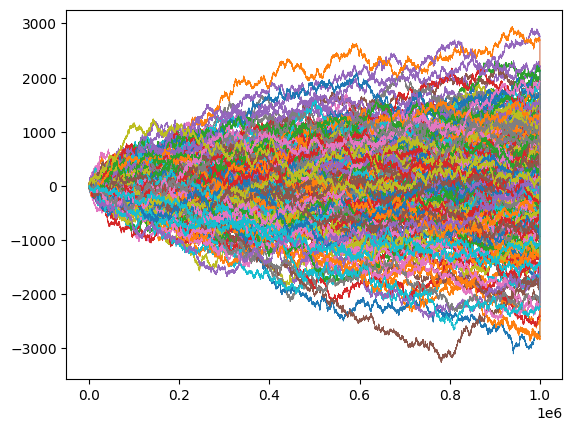

In [12]:
numbers = len(S) / MAX

plt.figure()

runnings = []
cycles = []

for i in range(MIN, MAX+1):
    start = int((i * numbers))
    stop = int((i+1) * numbers)
    roi, r = partial_sum(X[start:stop])
    runnings.append(r)
    cycles_ = len(roi) - np.count_nonzero(roi)
    cycles_ += 1
    cycles.append(cycles_)
    x = np.arange(0, len(roi), 1)
    plt.plot(x, roi, linewidth=0.5)
    
plt.savefig("../figures/random_excursions.pdf")

In [13]:
np.mean(cycles)

np.float64(819.6374501992032)

In [14]:
np.median(cycles)

np.float64(673.0)

In [15]:
((np.asarray(cycles)) < 500).sum() 

np.int64(96)

In [19]:
np.std(cycles)

np.float64(630.0319096705025)

In [16]:
# Compute amount of cycles: Step 4
S, _ = partial_sum(X)
J = S.count(0) - 1 # Leading zero

# Get constraint
constraint = max(0.005*(len(epsilon)**0.5), 500)

if J < constraint:
    print(f"J is < 500: {J}")

In [17]:
J

19630

In [18]:
# Get cycles (step 4)
cycles_mask = (np.array(S) == 0)
cycles_positions = []
for i in range(len(cycles_mask)):
    if cycles_mask[i] == True:
        cycles_positions.append(i)

KeyboardInterrupt: 

In [ ]:
# Get individual cycles (step 4)
cycles = []
for i in range(1, len(cycles_positions)):
    cycles.append(S[cycles_positions[i-1]:cycles_positions[i]+1])


In [23]:
# Create frequency state-cycle matrix (Step 5)
frequency_matrix = []
considered = 0

for cycle in cycles:
    states = []
    cycle = np.array(cycle)
    
    # Get state count per cycle
    for i in range(-4, 5):
        if i == 0:
            continue
        state_count = int((cycle == i).sum())
        states.append(state_count)
        considered += state_count
        
    frequency_matrix.append(states)   

In [24]:
considered / len(epsilon) *100

0.0636104

In [25]:
considered

159026

In [26]:
# Transform matrix for step 6
frequency_matrix = np.array(frequency_matrix).T

In [27]:
# Get number of states/cycle
states_matrix = []

for i in range(6):
    state_count = []
    for state in frequency_matrix:
        count = 0
        if i == 5:
            count = int(((state) >= i).sum())
        else:
            count = int(((state) == i).sum())
        state_count.append(count)
    states_matrix.append(state_count)

states_matrix = np.array(states_matrix).T

In [28]:
states_matrix

array([[17160,   282,   261,   252,   178,  1497],
       [16330,   569,   423,   383,   317,  1608],
       [14671,  1224,   937,   643,   576,  1579],
       [ 9776,  4895,  2396,  1285,   633,   645],
       [ 9854,  4871,  2444,  1246,   608,   607],
       [14724,  1222,   925,   689,   506,  1564],
       [16354,   564,   446,   367,   295,  1604],
       [17212,   303,   232,   221,   210,  1452]])

In [29]:
# Define population distributions
distributions = np.array([
    [0.5000000000, 0.25000000000, 0.12500000000, 0.06250000000, 0.03125000000, 0.0312500000],
	[0.7500000000, 0.06250000000, 0.04687500000, 0.03515625000, 0.02636718750, 0.0791015625],
	[0.8333333333, 0.02777777778, 0.02314814815, 0.01929012346, 0.01607510288, 0.0803755143],
    [0.8750000000, 0.01562500000, 0.01367187500, 0.01196289063, 0.01046752930, 0.073272705]
])

In [30]:
# Create a matrix that has equal indicies with states matrix
pi = np.array([
    distributions[3],
    distributions[2],
    distributions[1],
    distributions[0],
    distributions[0],
    distributions[1],
    distributions[2],
    distributions[3],
])

In [31]:
# Compute test statistics
statistics = []
for i in range(8): # iterate over states
    statistic = 0
    # iterate over cycles
    for j in range(6):
        observation = states_matrix[i][j]
        expectation = pi[i][j]
        intermediate = ((observation - J * expectation)**2) / (J* expectation)
        statistic += intermediate
    statistics.append(statistic)

In [32]:
statistics

[np.float64(9.532067743805463),
 np.float64(3.88606703455092),
 np.float64(10.747475204870348),
 np.float64(6.547529291900153),
 np.float64(0.8790626591951095),
 np.float64(0.38757256152399644),
 np.float64(2.9334134965312275),
 np.float64(6.0945554774855575)]

In [33]:
# Compute p-values
from scipy.special import gammaincc

pvalues = []
for s in statistics:
    pvalues.append(gammaincc(2.5, s / 2.0))    

In [34]:
pvalues

[np.float64(0.08963300021799572),
 np.float64(0.565933506334152),
 np.float64(0.05662317348121177),
 np.float64(0.25652310199589573),
 np.float64(0.9717188702628422),
 np.float64(0.9956649872219532),
 np.float64(0.7102508864641117),
 np.float64(0.29712671101467475)]

In [21]:
# Let's see whether a run is a large one, see Revesz
from math import log

In [22]:
n = 250 * 10**6

In [23]:
(2*n*(log(log(n)) + 3 * log(log(log(n/2)))))**0.5

55598.697996213734

In [24]:
eps = 0.0001

(1-eps)*(2*n*log(log(n)))**0.5

38480.03709589066

In [25]:
(2*n*log(log(n)))**0.5

38483.8854844391

In [26]:
# Largest run of ones, see Revesz
log(len(S), 2)

27.89735286552782

In [27]:
n**0.5 < 19630

True

In [28]:
n**0.5

15811.388300841896